In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
from IPython.core.display import HTML 
from scipy.integrate import odeint,solve_ivp
import networkx as nx
import EoN
import sympy as sp

In [2]:
import matplotlib as mpl
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["font.family"] = "STIXGeneral"

In [3]:
## disease parameters
beta = 0.48
gamma = 1

### SIR model on networks

Consider a chain network with three nodes labeled as A,B, and C as shown in below figure. Each of the three nodes can acquire one of the three states that are S,I, and R. Let $W(t) = (W_A(t),W_B(t),W_C(t))$ denotes the state vector at time $t$ and let $P(W(t))$ denote the probability that system is in state $W(t)$ at time $t$. There are $27$ combinations of states possible in this case. 

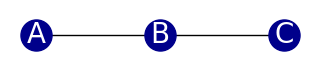

In [4]:
G = nx.Graph()
G.add_nodes_from([1,2,3])
G.add_edges_from([(1,2),(2,3)])
plt.figure(figsize=(3,0.5))
nx.draw(G,pos=nx.bipartite_layout(G,set(G.nodes()),align='horizontal'),
        with_labels=True,node_size=500,font_color='white',font_size = 20,
       labels = {1:'A',2:'B',3:'C'}, node_color='darkblue')
# plt.title("Figure 1: A chain undirected network of 3 nodes.",y=-0.04,fontsize=10)
plt.show()

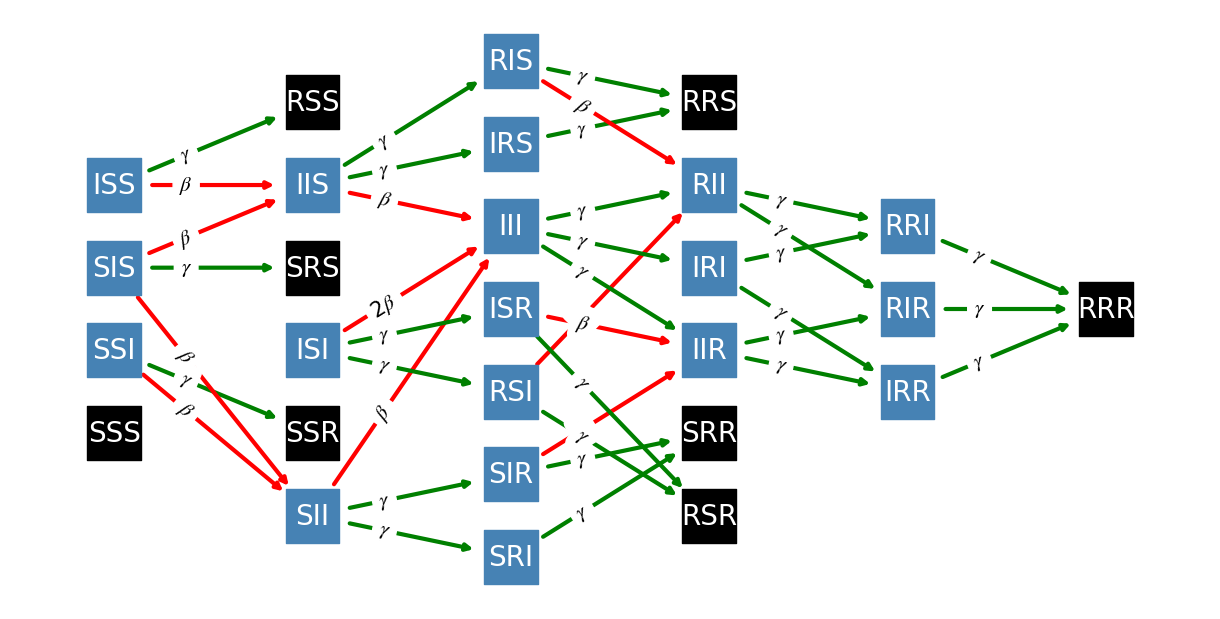

In [5]:
G = nx.DiGraph()
G.add_nodes_from(list(range(1,28)))
node_label_dict = {1:'SSS',2:'SSI',3:'SIS',4:"ISS",5:'SII',6:'SSR',7:'ISI',8:'SRS',9:'IIS',10:'RSS',
                  11:'SRI',12:'SIR',13:'RSI',14:'ISR',15:'III',16:'IRS',17:'RIS',18:'RSR',19:'SRR',
                   20:'IIR',21:'IRI',22:'RII',23:'RRS',24:'IRR',25:'RIR',26:'RRI',27:'RRR'
                  }
G.add_edges_from([(2,5),(2,6),(3,5),(3,8),(3,9),(4,9),(4,10),
                  (5,11),(5,12),(5,15),(7,13),(7,14),(7,15),(9,15),(9,16),(9,17),
                  (11,19),(12,19),(12,20),(13,22),(13,18) ,(14,18),(14,20),(15,20),(15,21),(15,22),(16,23),(17,22),(17,23),
                  (20,24),(20,25),(21,24),(21,26),(22,25),(22,26),
                  (24,27),(25,27),(26,27)
                 ])
layers = {"a":[1,2,3,4],"b":[5,6,7,8,9,10],"c":[11,12,13,14,15,16,17],"d":[18,19,20,21,22,23],"e":[24,25,26],"f":[27]}
layers_dict = {}
for key in layers.keys():
    for i in layers[key]:
        layers_dict[i] = key
colormap = []
for node in G.nodes():
    if node in [1,10,6,8,18,19,23,27]: colormap.append("black")
    else : colormap.append("steelblue")

edgemap = []
edge_labels = {}
for edge in G.edges():
    if edge in [(2,5),(3,5),(3,9),(4,9),(5,15),(7,15),(9,15),(12,20),(13,22),(14,20),(17,22)]:
        edgemap.append("red")
        edge_labels[edge] = f'$\\beta$'
        if edge == (7,15):
            edge_labels[edge] = f'2$\\beta$'
    else : 
        edgemap.append("green")
        edge_labels[edge] = f'$\\gamma$'

nx.set_node_attributes(G,layers_dict,name='subset')
plt.figure(figsize=(12,6))
nx.draw(G,pos = nx.multipartite_layout(G),node_shape='s',node_size=1500
        ,with_labels=True,labels = node_label_dict,font_color='white',font_size=20
       ,node_color=colormap,width=3,edge_color=edgemap)
nx.draw_networkx_edge_labels(
    G, pos=nx.multipartite_layout(G),
    edge_labels=edge_labels,
    font_color='black',label_pos=0.35,font_size=15
)
plt.show()


In above figure, all possible transitions are shown between each 27 possible combination of states for the chain network. The state combination in above figure aligns with the order of nodes in chain network, i.e., SSI implies $W_A(t)= $S, $W_B(t) = $S and $W_C(t)=$I. The red color edges denote an infection transmission event and green color edges denote a recovery event. The states with black color box are the absorbing states, i.e., system can not move anywhere from them. Let's write the rate of change $P(W(t))$ for $27$ state combinations using above figure.
\begin{align}
\dot{P(SSS)} &= 0 \\
\dot{P(SSI)} &= -(\beta + \gamma) P(SSI) \\
\dot{P(SIS)} &= -(2\beta+ \gamma) P(SIS) \\
\dot{P(ISS)} &= -(\beta + \gamma) P(ISS) \\
\dot{P(SII)} &= -2\gamma P(SII) + \beta P(SSI) + \beta P(SIS) \\
\dot{P(ISI)} &= -(2\gamma + 2\beta )P(ISI) \\
\dot{P(IIS)} &= -(\beta+2\gamma)P(IIS) + \beta P(SIS) +  \beta P(ISS)\\
\dot{P(SRI)} &= -\gamma P(SRI) + \gamma P(SII)\\
\dot{P(SIR)} &= -(\gamma+\beta) P(SIR) + \gamma P(SII)\\
\dot{P(RSI)} &= -(\gamma+\beta) P(RSI) + \gamma P(ISI)\\
\dot{P(ISR)} &= -(\gamma+\beta)P(ISR) + \gamma P(ISI) \\
\dot{P(III)} &= -3\gamma P(III) + \beta P(SII) + 2\beta P(ISI) +  \beta P(IIS)\\
\dot{P(IRS)} &= -\gamma P(IRS) + \gamma P(IIS)\\
\dot{P(RIS)} &= - (\beta + \gamma) P(RIS) + \gamma P(IIS)\\
\dot{P(IIR)} &= -2\gamma P(IIR) + \beta P(SIR) +\beta P(ISR) + \gamma P(III)\\
\dot{P(IRI)} &= -2\gamma P(IRI) + \gamma P(III)\\
\dot{P(RII)} &= -2\gamma P(RII) + \beta P(RSI) +\beta P(RIS)+ \gamma P(III)\\
\dot{P(IRR)} &= -\gamma P(IRR) + \gamma P(IIR) + \gamma P(IRI)\\
\dot{P(RIR)} &= -\gamma P(RIR) + \gamma P(IIR) + \gamma P(RII)\\
\dot{P(RRI)} &= -\gamma P(RRI) + \gamma P(IRI) + \gamma P(RII)\\
\dot{P(RRR)} &= \gamma(P(IRR)+P(RIR)+P(RRI))\\
\dot{P(SSR)} &= \gamma P(SSI)  \\
\dot{P(SRS)} &= \gamma P(SIS) \\
\dot{P(RSS)} &= \gamma P(ISS) \\
\dot{P(RSR)} &= \gamma (P(ISR) + P(RSI)) \\
\dot{P(SRR)} &= \gamma (P(SIR) + P(SRI)) \\
\dot{P(RRS)} &=  \gamma (P(IRS) + P(RIS))
\end{align}

Let's solve the equations in (8) for a specific initial condition that is, $P_0(ISS) = 1$ and probability of being in any other state at $t=0$ is $0$. This leads to the following solutions 
\begin{align}
P(SSI) &= P(SIS) = P(ISI) = P(SII) = 0 \\
P(ISS) &= \exp(-t(\beta+\gamma)) \\
P(IIS)  &= \frac{\beta}{\gamma} (\exp(-t(\beta+\gamma)) - \exp(-t(\beta+2\gamma))) \\
P(III) &= \frac{\beta^2}{(\gamma-\beta)(2\gamma-\beta)}\exp(-3\gamma t) + \frac{\beta^2}{\gamma} \big( \frac{\exp(-t(\beta+\gamma))}{2\gamma-\beta} - \frac{\exp(-t(\beta+2\gamma))}{\gamma-\beta}   \big) \\
\end{align}

In [6]:
## analytical solution
# only for initial condition ISS 
def analytical_sol(t_ls,b,g):
    t = sp.symbols('t')
    ISS,IIS,ISI,SSI,SIS,SII,III,RSS,IRS,RIS,RRS,IRI,RSI,RII,SIR,ISR,IIR,IRR,RIR,RRI,RRR = sp.symbols('ISS IIS ISI SSI SIS SII III RSS IRS RIS RRS IRI RSI RII SIR ISR IIR IRR RIR RRI RRR', cls=sp.Function)
    constants = sp.symbols('beta gamma')
    equations = [sp.Eq(ISS(t).diff(t),-(gamma+beta)*ISS(t)),
                sp.Eq(IIS(t).diff(t),beta*ISS(t)-2*gamma*IIS(t)-beta*IIS(t)),
                    sp.Eq(ISI(t).diff(t),-2*(beta+gamma)*ISI(t)),
                    sp.Eq(SSI(t).diff(t),-(beta+gamma)*SSI(t)),
                    sp.Eq(SIS(t).diff(t),-(2*beta+gamma)*SIS(t)),
                    sp.Eq(SII(t).diff(t),-2*(beta+gamma)*SII(t) + beta*SSI(t) + beta*SIS(t)),
                    sp.Eq(III(t).diff(t),beta*IIS(t) + beta*ISI(t) + beta*SII(t) - 3*gamma*III(t)),
                    sp.Eq(RSS(t).diff(t),gamma*ISS(t)),
                    sp.Eq(IRS(t).diff(t),gamma*(IIS(t)-IRS(t))),
                    sp.Eq(RIS(t).diff(t),gamma*IIS(t) - (gamma+beta)*RIS(t)),
                    sp.Eq(RRS(t).diff(t),gamma*(RIS(t)+IRS(t))),
                    sp.Eq(IRI(t).diff(t),gamma*III(t)-2*gamma*IRI(t)),
                    sp.Eq(RSI(t).diff(t),gamma*ISI(t)  - (gamma+beta)*RSI(t)),
                    sp.Eq(RII(t).diff(t),beta*(RSI(t)+RIS(t)) + gamma*III(t) - 2*gamma*RII(t)),
                    sp.Eq(SIR(t).diff(t),gamma*SII(t) - (gamma+beta)*SIR(t)),
                    sp.Eq(ISR(t).diff(t),gamma*ISI(t) - (beta+gamma)*ISR(t)),
                    sp.Eq(IIR(t).diff(t),beta*(SIR(t)+ISR(t)) + gamma*III(t) - 2*gamma*IIR(t)),
                    sp.Eq(IRR(t).diff(t),gamma*(IIR(t)+IRI(t))-gamma*IRR(t)),
                    sp.Eq(RIR(t).diff(t),gamma*(IIR(t)+RII(t))-gamma*RIR(t)),
                    sp.Eq(RRI(t).diff(t),gamma*(RII(t)+IRI(t))-gamma*RRI(t)),
                    sp.Eq(RRR(t).diff(t),gamma*(IRR(t)+RIR(t)+RRI(t)))

            ]
    solutions = sp.dsolve(equations,constants=constants,ics = {ISS(0):1,IIS(0):0,ISI(0):0,SSI(0):0,SIS(0):0,SII(0):0,III(0):0,RSS(0):0,IRS(0):0,RIS(0):0,RRS(0):0
                                                               ,IRI(0):0,RSI(0):0,RII(0):0,SIR(0):0, ISR(0):0, IIR(0):0,IRR(0):0,RIR(0):0,RRI(0):0,RRR(0):0
                                                               })
    constant_values = {beta:b,gamma:g}
    keys = 'ISS IIS ISI SSI SIS SII III RSS IRS RIS RRS IRI RSI RII SIR ISR IIR IRR RIR RRI RRR'.split(" ")
    analytical_results = {}
    for i,sol in enumerate(solutions):
        solution = sol.subs(constant_values)
        x_solution = [sol.rhs.subs(t, val) for val in t_ls]
        analytical_results[keys[i]] = x_solution
    return analytical_results


In [7]:
## numerical solution, solving the system of ODEs using scipy library
def ode_SIR_3(y,t,beta,gamma):
    ISS,IIS,ISI,SSI,SIS,SII,III,RSS,IRS,RIS,RRS,IRI,RSI,RII,SIR,ISR,IIR,IRR,RIR,RRI,RRR = y
    dydt = [-(gamma+beta)*ISS,
           beta*ISS-2*gamma*IIS-beta*IIS,
            -2*(beta+gamma)*ISI,
            -(beta+gamma)*SSI,
            -(2*beta+gamma)*SIS,
            -2*(beta+gamma)*SII + beta*SSI + beta*SIS,
            beta*IIS + beta*ISI + beta*SII - 3*gamma*III,
            gamma*ISS,
            gamma*(IIS-IRS),
            gamma*IIS - (gamma+beta)*RIS,
            gamma*(RIS+IRS),
            gamma*III-2*gamma*IRI,
            gamma*ISI  - (gamma+beta)*RSI,
            beta*(RSI+RIS) + gamma*III - 2*gamma*RII,
            gamma*SII - (gamma+beta)*SIR,
            gamma*ISI - (beta+gamma)*ISR,
            beta*(SIR+ISR) + gamma*III - 2*gamma*IIR,
            gamma*(IIR+IRI)-gamma*IRR,
            gamma*(IIR+RII)-gamma*RIR,
            gamma*(RII+IRI)-gamma*RRI,
            gamma*(IRR+RIR+RRI)
           ]
    return dydt 

In [8]:
### Gillespie simulation using EoN library
def gillespie(beta,gamma,initial_infected,epochs,time_points,status_list):
    G = nx.Graph()
    G.add_nodes_from([1,2,3])
    G.add_edges_from([(1,2),(2,3)])
    sim_results = {'t':[],'node_status':[]}
    for i in range(epochs):
        sim_obj = EoN.Gillespie_SIR(G,tau=beta,gamma =gamma,initial_infecteds=initial_infected
                                    ,return_full_data=True,tmax=10)
        t,_ = sim_obj.summary()
        node_status = []
        for i in t:
            status = ''
            for node in G.nodes(): status+=sim_obj.node_status(node,i)
            node_status.append(status)
        sim_results['t'].append(t)
        sim_results['node_status'].append(node_status)
        
    status_dict = {st:[] for st in status_list}
    status_sub_dict = {}
    for j,tt in enumerate(time_points):
        sim_status_sub = []
        for ind, t_ls in enumerate(sim_results['t']):
            states_sub = []
            for i,ti in enumerate(t_ls):
                if ti <= tt and i<len(t_ls)-1 and t_ls[i+1] > tt  : states_sub.append(sim_results['node_status'][ind][i])
                elif i>=len(t_ls)-1 and ti <= tt : states_sub.append(sim_results['node_status'][ind][i])
            sim_status_sub.append(states_sub)
        status_sub_dict[tt] = sim_status_sub

    for prob_status in status_dict.keys():
        prob_ls = []
        for key in status_sub_dict.keys():
            cnt = 0
            for i in status_sub_dict[key] : 
                if prob_status in i : cnt+=1
            prob_ls.append(cnt/len(status_sub_dict[key]))
        status_dict[prob_status] = prob_ls
                
    return status_dict,sim_results


In [9]:
## initial values and disease parameter values
y0 =   [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
t = np.linspace(0, 10, 100)
beta,gamma = 0.48,1
statuses = 'ISS IIS ISI SSI SIS SII III RSS IRS RIS RRS IRI RSI RII SIR ISR IIR IRR RIR RRI RRR'.split(" ")


## analytical solution
analytical_result = analytical_sol(t,beta,gamma)

## numerical solution
solution = odeint(ode_SIR_3, y0, t,args=(beta,gamma))
numerical_result = {val:solution[:,i] for i,val in enumerate(statuses) }


## Gillespie simulation solution
req_status_ls = 'ISS IIS RSS III IRS RIS RRS RII IRI IIR IRR RIR RRI RRR'.split(" ")
# change the number of epochs for increasing or decreasing the number of Gillespie simulation
epochs = 1000000
gillespie_result,sim_results = gillespie(beta,gamma,[1],epochs,t,req_status_ls)

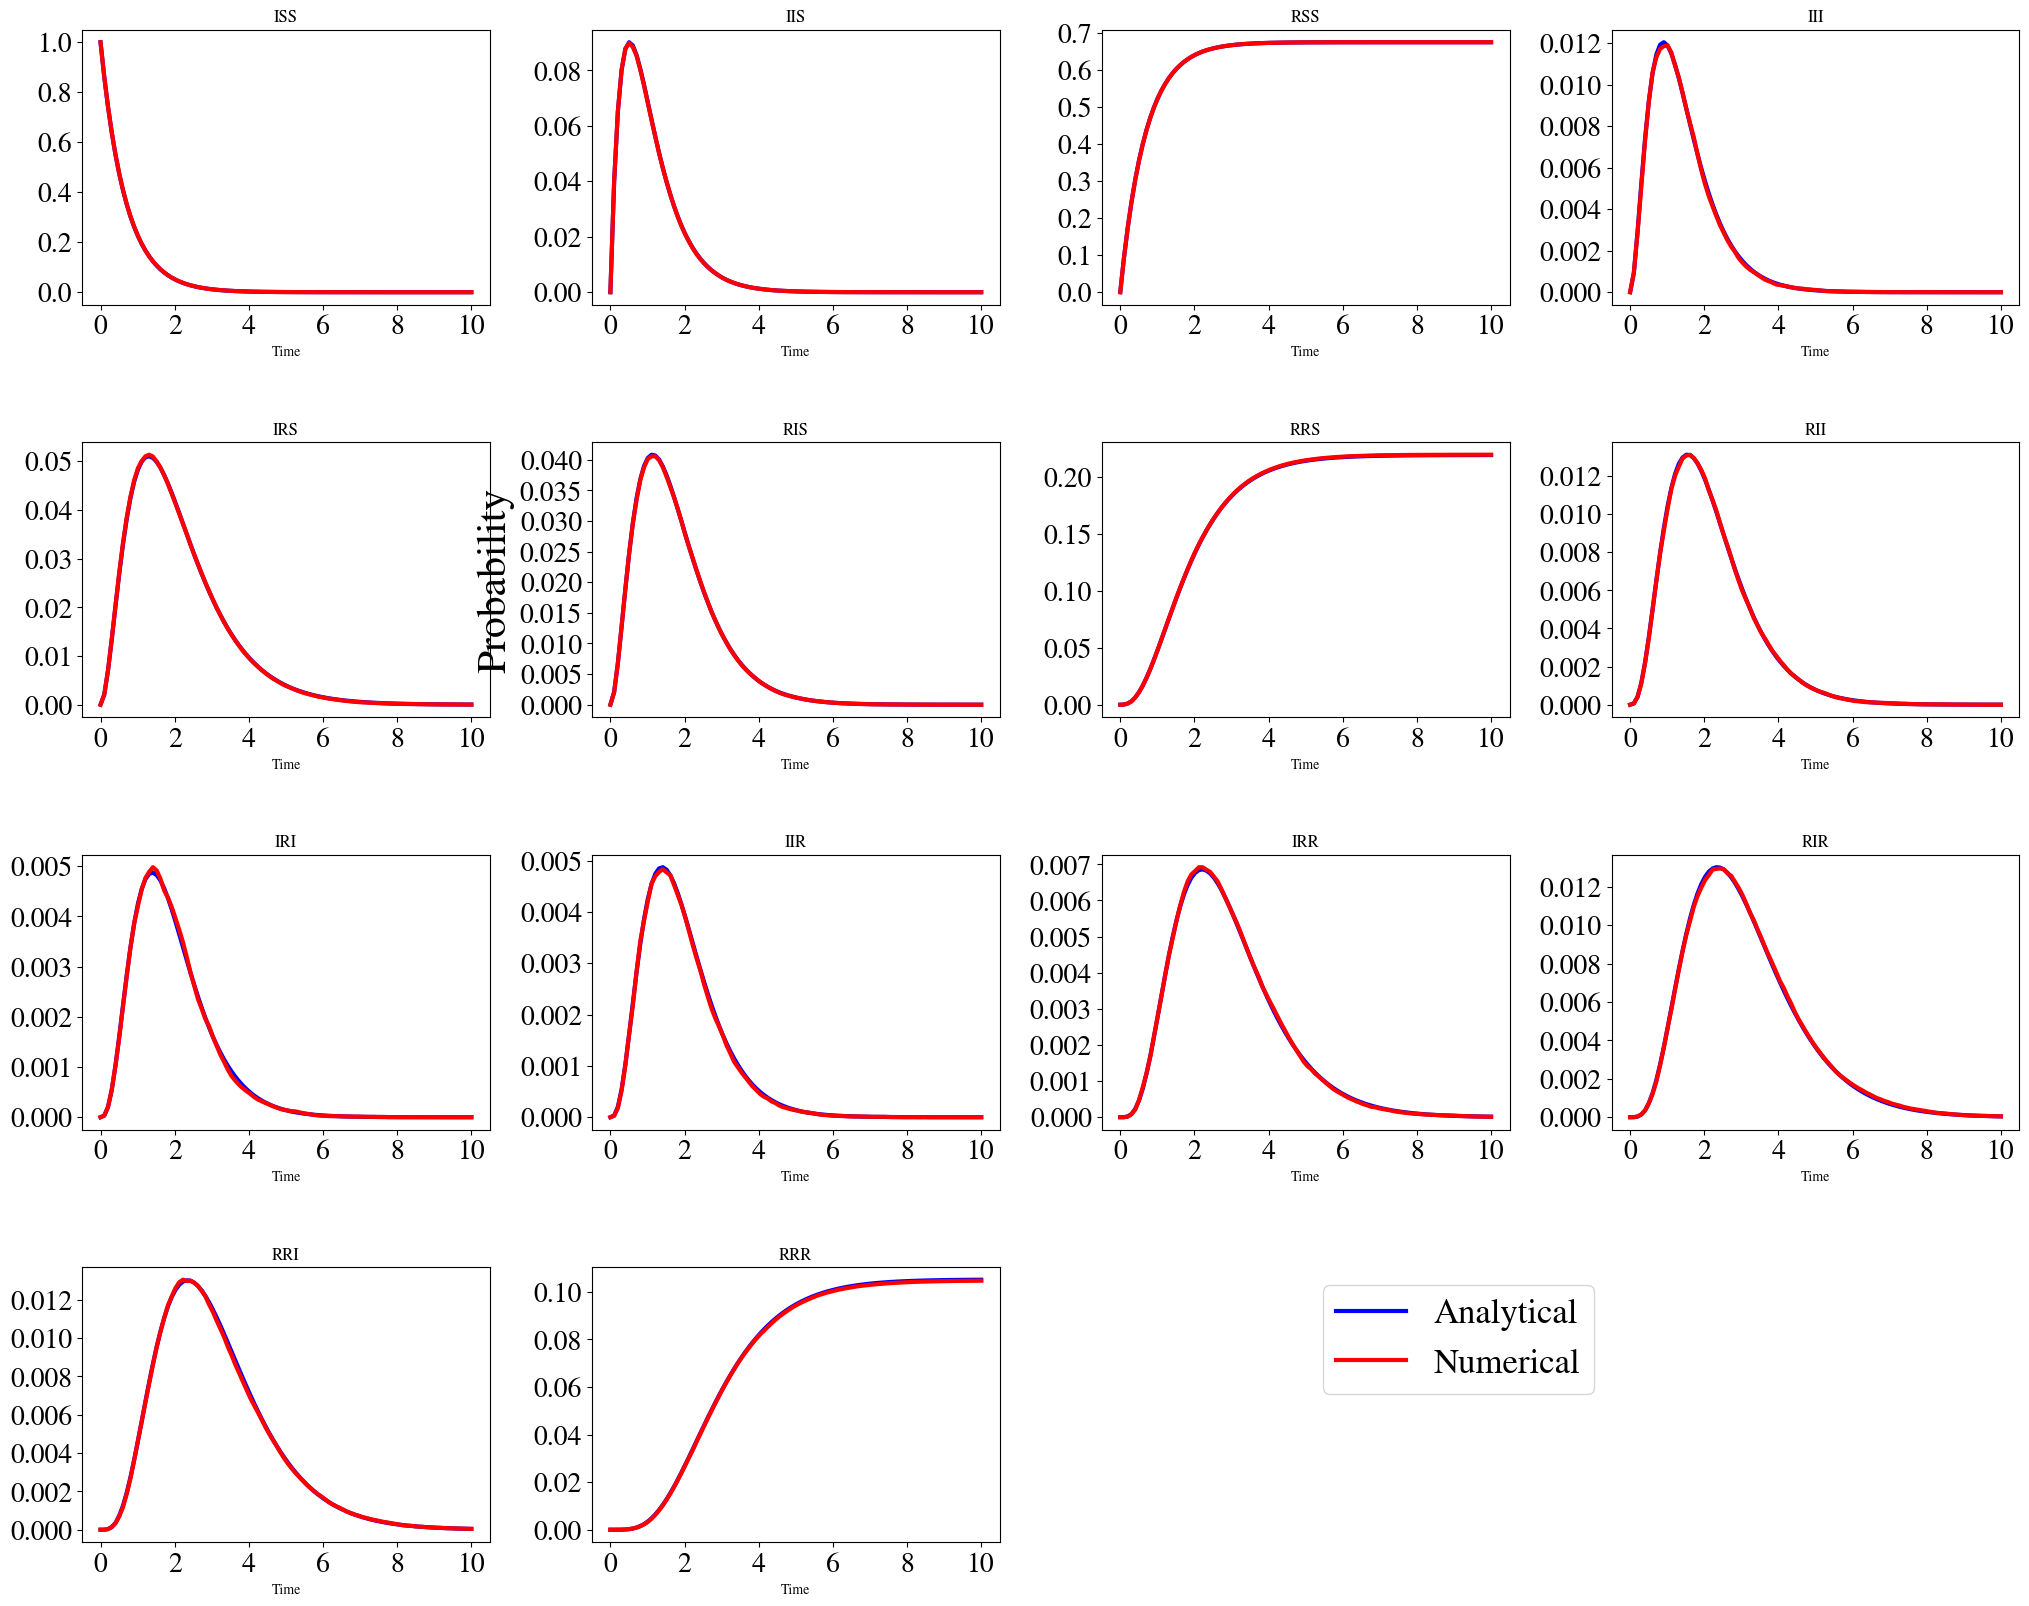

In [10]:
plt.figure(figsize=(25,25))

plt.subplots_adjust(wspace=0.25,hspace=0.5)
nrow = 5
ncol = 4
for i,key in enumerate(req_status_ls):
    plt.subplot(nrow,ncol,i+1)
    plt.plot(t,analytical_result[key],label=f'{key}-grey',color='blue', lw=3)
    # plt.plot(t,numerical_result[key],label=f'{key}-numerical',color='blue',linestyle='--', lw=4)
    plt.plot(t,gillespie_result[key],label=f'{key}-gillespie',color='red',linestyle='-', lw=3)
    plt.title(f"{key}")
    plt.xlabel("Time")
    if i == 5:
        plt.ylabel("Probability",fontsize=30)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)

plt.legend(['Analytical','Numerical','Gillespie'],bbox_to_anchor=(2.5, 1),fontsize=25)
